# Shap on 6 features - embeddings based

Initial run as always to th get the right working folder + One more for imports

In [2]:
import os
import sys

# 1. Change the working directory to the project root
%cd ..

# 2. Add the root directory to the Python path so imports work
sys.path.append(os.getcwd())

# 3. Verify we are in the right place
print(f"Current Working Directory: {os.getcwd()}")
# !ls # Optional: list files to confirm you see 'main.py' and 'pbi_utils'p

/data/pavel.degterev/pbi
Current Working Directory: /data/pavel.degterev/pbi


In [ ]:
import shap
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

# from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput, EmbeddingsManager
# from main import parse_config #, Stats, make_dataset, create_embeddings_bacteria, create_embeddings_phages, logger

from tqdm.auto import tqdm
from pbi_utils.logging import Logging, INFO, DEBUG
from pbi_utils.data_manager import H5pyEmbeddingsManager
from pbi_utils.config_parser_XAI import parse_config
#from main import parse_config

# from pbi_utils.types import CACHED_EMBEDDINGS_OPTION # bool | Literal["auto"]

## initialization

In [ ]:
tqdm.pandas()  # Initialize tqdm with pandas
Logging.set_logging_level(DEBUG)
# logger = Logging()

# CONFIG_PATH = "model_configs/best_model_XAI.yaml"
CONFIG_PATH = 'XAI/bundle/best_model_XAI.yaml' 
config = parse_config(CONFIG_PATH)
DEVICE = config.device

[DEBUG] [NT2] Using InstaDeepAI default model weights


/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[DEBUG] [NT2] Using InstaDeepAI default model weights
[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[INFO] Configuration loaded from model_configs/best_model_XAI.yaml: Config(input_perphect=bacteria_df='data/perphect-data/all/bacteria_df.csv' phages_df='data/perphect-data/all/phages_df.csv' couples_df='data/perphect-data/all-private-oversampled/couples_df.csv', embeddings_dir=data/embeddings, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_fact

### Confighuration
With ability to run only those changes that actually needed

In [5]:
# Raw (pre-PCA) block boundaries in the 18,824-dim flat embedding

BACT_BLOCKS = {
    "bact_NT2":      (0,    1536),
    "bact_MegaDNA":  (1536, 2500),
    "bact_DNABERT2": (2500, 4036),
}
BACT_DIM = 4036

# phage_embedding is shape (14788,): NT2 | MegaDNA | DNABERT2
PHAG_BLOCKS = {
    "phag_NT2":      (0,    1536),
    "phag_MegaDNA":  (1536, 2500),
    "phag_DNABERT2": (2500, 14788),
}
PHAG_DIM = 14788

# Combined block boundaries in the flat (4036 + 14788 = 18824) space
# phage offsets are shifted by BACT_DIM
BLOCKS = {**BACT_BLOCKS,
          **{k: (s + BACT_DIM, e + BACT_DIM) for k, (s, e) in PHAG_BLOCKS.items()}}
BLOCK_NAMES = list(BLOCKS.keys())
N_BLOCKS = len(BLOCK_NAMES)   # 6
TOTAL_DIM = BACT_DIM + PHAG_DIM  # 18824

def tensor_to_numpy(t):
    return t.detach().cpu().numpy()

print("Block definitions (in flat 18824-dim space):")
for name, (s, e) in BLOCKS.items():
    print(f"  {name}: [{s}:{e}] ({e - s} dims)")

Block definitions (in flat 18824-dim space):
  bact_NT2: [0:1536] (1536 dims)
  bact_MegaDNA: [1536:2500] (964 dims)
  bact_DNABERT2: [2500:4036] (1536 dims)
  phag_NT2: [4036:5572] (1536 dims)
  phag_MegaDNA: [5572:6536] (964 dims)
  phag_DNABERT2: [6536:18824] (12288 dims)


In [6]:
# I guess that here should be custom embeddings folder to not mess up OG embeddings
CUSTOM_EMBEDDINGS_FOLDER = "XAI/embeddings"
output_manager = H5pyEmbeddingsManager(CUSTOM_EMBEDDINGS_FOLDER)
#output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from XAI/embeddings


In [7]:
FILTERED_PAIRS = [
    {"id": 788, "bacterium_id": 153, "phage_id": 2014},
    {"id": 939, "bacterium_id": 153, "phage_id": 2153},
    {"id": 2271, "bacterium_id": 1869, "phage_id": 6187},
    {"id": 741, "bacterium_id": 5859, "phage_id": 451},
    {"id": 728, "bacterium_id": 5859, "phage_id": 5924},
    {"id": 768, "bacterium_id": 5859, "phage_id": 5928},
] # first one is the test pair

In [23]:
TEST_PAIR = FILTERED_PAIRS[2]

### Loading the dataset aka meta embeddings

In [9]:
# load option
emb_test_data = torch.load(config.test_path, map_location=DEVICE)
emb_test_data = emb_test_data.reset_index(drop=True)
emb_test_data.head() # embeddings from the test part in the training stage

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,1127,2318,1869,1,"[tensor(-0.2436, device='cuda:0'), tensor(0.46...","[tensor(-0.4400, device='cuda:0'), tensor(0.56..."
1,4505,4095,1869,0,"[tensor(-0.2436, device='cuda:0'), tensor(0.46...","[tensor(0.3543, device='cuda:0'), tensor(-0.05..."
2,7056,5303,5196,0,"[tensor(-0.0618, device='cuda:0'), tensor(0.18...","[tensor(-0.0118, device='cuda:0'), tensor(0.18..."
3,6430,5322,5201,0,"[tensor(-0.1654, device='cuda:0'), tensor(0.29...","[tensor(-0.1430, device='cuda:0'), tensor(0.33..."
4,3605,2246,5859,0,"[tensor(-0.1581, device='cuda:0'), tensor(0.44...","[tensor(-0.1737, device='cuda:0'), tensor(0.38..."


In [10]:
len(emb_test_data['phage_embedding'])

1426

In [11]:
len(emb_test_data['phage_embedding'].iloc[0])

14788

### Loading from the config and appling PCA

In [10]:
with open(config.bacteria_pca_path, 'rb') as f:
    pca_bact = pickle.load(f)
#emb_test_data["bacterium_embedding"] = list(torch.from_numpy(pca_bact.transform(emb_test_data["bacterium_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore

with open(config.phage_pca_path, 'rb') as f:
    pca_phag = pickle.load(f)
#emb_test_data["phage_embedding"] = list(torch.from_numpy(pca_phag.transform(emb_test_data["phage_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore


### Loading model

In [11]:
bacterium_embed_size = 500 #len(emb_test_data["bacterium_embedding"].iloc[0]) # always 500 ???
phage_embed_size = 500 #len(emb_test_data["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(config.model_path, map_location=DEVICE))

/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


<All keys matched successfully>

In [12]:
# ── Background option 3: deduplicated organisms, one row per unique ID ────────
# Strategy: for each unique bacterium_id, take the first row it appears in.
# For each unique phage_id, take the first row it appears in.
# Then concatenate and deduplicate the resulting flat embeddings.

unique_bact_rows = emb_test_data.drop_duplicates(subset='bacterium_id')
unique_phag_rows = emb_test_data.drop_duplicates(subset='phage_id')

# Build flat embeddings for unique bacteria rows
# (use their actual phage partner — we only care about the bact block anyway)
X_unique_bact = np.stack([
    np.concatenate([
        tensor_to_numpy(row['bacterium_embedding']),
        tensor_to_numpy(row['phage_embedding']),
    ])
    for _, row in unique_bact_rows.iterrows()
])  # (166, 18824)

# Build flat embeddings for unique phage rows
X_unique_phag = np.stack([
    np.concatenate([
        tensor_to_numpy(row['bacterium_embedding']),
        tensor_to_numpy(row['phage_embedding']),
    ])
    for _, row in unique_phag_rows.iterrows()
])  # (860, 18824)

# Combine and deduplicate by exact row equality
X_dedup = np.unique(
    np.concatenate([X_unique_bact, X_unique_phag], axis=0),
    axis=0
)
print(f'Deduplicated background shape: {X_dedup.shape}')
# Will be somewhere between 860 and 1026 rows

Deduplicated background shape: (935, 18824)


### Baseline crosscheck for phage & bacteria

In [13]:
model.to(DEVICE)
model.eval()

def predict_fn(X):
    bact_pca  = pca_bact.transform(X[:, :BACT_DIM]).astype(np.float32)
    phage_pca = pca_phag.transform(X[:, BACT_DIM:]).astype(np.float32)
    bact_t  = torch.from_numpy(bact_pca).to(DEVICE)
    phage_t = torch.from_numpy(phage_pca).to(DEVICE)
    with torch.inference_mode():
        probs = torch.softmax(model(bact_t, phage_t), dim=1)[:, 1]
    return probs.cpu().numpy()


row = emb_test_data.loc[emb_test_data["id"] == TEST_PAIR["id"]].iloc[0]

test_row = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
])

# What does the model predict when one organism is pure baseline (mean)?
# bact_mean_row = np.concatenate([X_dedup, tensor_to_numpy(row["phage_embedding"])])
# phag_mean_row = np.concatenate([tensor_to_numpy(row["bacterium_embedding"]), baseline_phag])
# both_mean_row = baseline_full.copy()

# print(f'Cross check for bacteria #{TEST_PAIR["bacterium_id"]} & phage #{TEST_PAIR["phage_id"]} \n(pair id {TEST_PAIR["id"]})\n')
# print(f"Real pair prediction:        {predict_fn(test_row)[0]:.4f}")
# print(f"Phage real, bact=mean:       {predict_fn(bact_mean_row.reshape(1,-1))[0]:.4f}")
# print(f"Bact real, phage=mean:       {predict_fn(phag_mean_row.reshape(1,-1))[0]:.4f}")
# print(f"Both mean (baseline):        {predict_fn(both_mean_row.reshape(1,-1))[0]:.4f}")

`max_samples=20` is set as a boundary before server GPU runs out of memory, each loop is apperantly stored in the RAM for all samples at one run

In [18]:
from tqdm.auto import tqdm
import shap

shap.utils.progress = tqdm

masker    = shap.maskers.Independent(X_dedup, max_samples=20)
explainer = shap.Explainer(predict_fn, masker)

In [27]:
TEST_PAIR = FILTERED_PAIRS[1]

row = emb_test_data.loc[emb_test_data["id"] == TEST_PAIR["id"]].iloc[0]

test_row = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
])


`Max_evals` set to the very minimum value of `amount of fetures`*2 + 1

In [33]:

sv = explainer(test_row, max_evals=37651, silent=False)

print('=== Block-level contributions ===')
for name, (s, e) in BLOCKS.items():
    contrib = float(abs(sv.values[0, s:e]).sum())
    print(f'  {name:<20s}: {contrib:+.6f}')

PermutationExplainer explainer: 2it [05:20, 320.62s/it]              

=== Block-level contributions ===
  bact_NT2            : +2.818119
  bact_MegaDNA        : +1.181131
  bact_DNABERT2       : +0.568614
  phag_NT2            : +3.324520
  phag_MegaDNA        : +0.663258
  phag_DNABERT2       : +0.512555


=== Block-level contributions ===
  bact_NT2            : +0.106298
  bact_MegaDNA        : +0.036966
  bact_DNABERT2       : +0.007570
  phag_NT2            : +0.284409
  phag_MegaDNA        : +0.038871
  phag_DNABERT2       : +0.170258


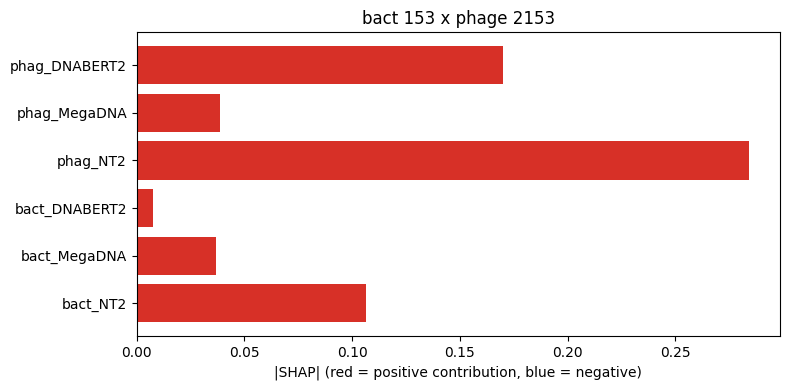

In [36]:
block_contribs = {}


print('=== Block-level contributions ===')
for name, (s, e) in BLOCKS.items():
    contrib = float(sv.values[0, s:e].sum())
    block_contribs[name] = contrib
    print(f'  {name:<20s}: {contrib:+.6f}')


fig, ax = plt.subplots(figsize=(8, 4))
names  = list(block_contribs.keys())
raw    = list(block_contribs.values())


values = [abs(v) for v in raw]
colors = ['#d73027' if v > 0 else '#4575b4' for v in raw]


ax.barh(names, values, color=colors)
ax.set_xlabel('|SHAP| (red = positive contribution, blue = negative)')
ax.set_title(
    f'bact {row["bacterium_id"]} x phage {row["phage_id"]}'
)
plt.tight_layout()
plt.savefig('XAI/kernel_shap_single_abs.png', dpi=150)
plt.show()

## Implementation

To obtain a reasonable explanation while working within memory limitations—which restrict the process to 20 comparison samples with 2 perturbations per feature—a loop of 5 runs was implemented. While this iterative approach successfully bypasses the hardware constraints, it represents a practical compromise in the sampling process.

In [30]:
import pandas as pd

all_runs = []

for run in range(5):
    print(f'\n--- Run {run + 1}/5 ---')
    sv = explainer(test_row, max_evals=37651, silent=False)
    
    run_contribs = {'run': run + 1}
    for name, (s, e) in BLOCKS.items():
        contrib = float(sv.values[0, s:e].sum())
        run_contribs[name] = contrib
        print(f'  {name:<20s}: {contrib:+.6f}')
    
    all_runs.append(run_contribs)
    
    # Show results so far after each run
    runs_df = pd.DataFrame(all_runs).set_index('run')
    display(runs_df)

print('\n=== Mean across 5 runs ===')
display(runs_df.mean().rename('mean'))

print('\n=== Std across 5 runs ===')
display(runs_df.std().rename('std'))


--- Run 1/5 ---


PermutationExplainer explainer: 2it [04:01, 242.00s/it]              

  bact_NT2            : +0.136755
  bact_MegaDNA        : +0.103896
  bact_DNABERT2       : -0.071226
  phag_NT2            : +0.233887
  phag_MegaDNA        : +0.080384
  phag_DNABERT2       : +0.160676


,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2
run,,,,,,
1,0.136755,0.103896,-0.071226,0.233887,0.080384,0.160676



--- Run 2/5 ---


...

,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2
run,,,,,,
1,0.136755,0.103896,-0.071226,0.233887,0.080384,0.160676
2,0.162757,0.160896,-0.009590,0.181259,0.034608,0.114443
3,0.132293,0.014908,-0.102384,0.274455,0.162495,0.162605
4,0.066261,0.264795,-0.042876,0.069818,0.065409,0.220966
5,0.209784,0.155524,-0.124247,0.143930,0.070197,0.189185



=== Mean across 5 runs ===


bact_NT2         0.141570
bact_MegaDNA     0.140004
bact_DNABERT2   -0.070065
phag_NT2         0.180670
phag_MegaDNA     0.082619
phag_DNABERT2    0.169575
Name: mean, dtype: float64


=== Std across 5 runs ===


bact_NT2         0.052160
bact_MegaDNA     0.091108
bact_DNABERT2    0.045766
phag_NT2         0.079476
phag_MegaDNA     0.047804
phag_DNABERT2    0.039347
Name: std, dtype: float64

In [31]:
runs_df.head()

,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2
run,,,,,,
1,0.136755,0.103896,-0.071226,0.233887,0.080384,0.160676
2,0.162757,0.160896,-0.009590,0.181259,0.034608,0.114443
3,0.132293,0.014908,-0.102384,0.274455,0.162495,0.162605
4,0.066261,0.264795,-0.042876,0.069818,0.065409,0.220966
5,0.209784,0.155524,-0.124247,0.143930,0.070197,0.189185


In [32]:
all_runs

[{'run': 1,
  'bact_NT2': 0.1367547504549717,
  'bact_MegaDNA': 0.10389648486112965,
  'bact_DNABERT2': -0.07122649604674283,
  'phag_NT2': 0.2338870574782288,
  'phag_MegaDNA': 0.08038419367391586,
  'phag_DNABERT2': 0.16067636979096156},
 {'run': 2,
  'bact_NT2': 0.1627573196976348,
  'bact_MegaDNA': 0.1608957442392338,
  'bact_DNABERT2': -0.009589975834285003,
  'phag_NT2': 0.18125867698757073,
  'phag_MegaDNA': 0.03460771900514123,
  'phag_DNABERT2': 0.11444287611716919},
 {'run': 3,
  'bact_NT2': 0.13229341323652175,
  'bact_MegaDNA': 0.014908434868717735,
  'bact_DNABERT2': -0.10238417755922644,
  'phag_NT2': 0.27445455846749073,
  'phag_MegaDNA': 0.16249485739037442,
  'phag_DNABERT2': 0.16260527380858655},
 {'run': 4,
  'bact_NT2': 0.06626125122295282,
  'bact_MegaDNA': 0.2647945539577527,
  'bact_DNABERT2': -0.042876170436578126,
  'phag_NT2': 0.0698180196221336,
  'phag_MegaDNA': 0.06540915841573475,
  'phag_DNABERT2': 0.220965547430469},
 {'run': 5,
  'bact_NT2': 0.209783602

In [ ]:
# Mean contributions across all runs
mean_contribs = runs_df.mean()

fig, ax = plt.subplots(figsize=(8, 4))
names  = list(mean_contribs.index)
raw    = list(mean_contribs.values)

values = [abs(v) for v in raw]
errors = [runs_df[name].std() for name in names]  # std as error bars
colors = ['#d73027' if v > 0 else '#4575b4' for v in raw]

bars = ax.barh(names, values, color=colors, xerr=errors,
               error_kw=dict(ecolor='black', capsize=4, linewidth=1.2))
ax.set_xlabel('|SHAP| (red = positive, blue = negative)')
ax.set_title(
    f'bact {row["bacterium_id"]} x phage {row["phage_id"]} — mean ± std over {len(runs_df)} runs'
)
plt.tight_layout()
plt.savefig('XAI/kernel_shap_mean_runs.png', dpi=150)
plt.show()

=== Block-level contributions ===
  bact_NT2            : +0.191235
  bact_MegaDNA        : +0.201107
  bact_DNABERT2       : -0.140765
  phag_NT2            : +0.103231
  phag_MegaDNA        : +0.132249
  phag_DNABERT2       : +0.157315


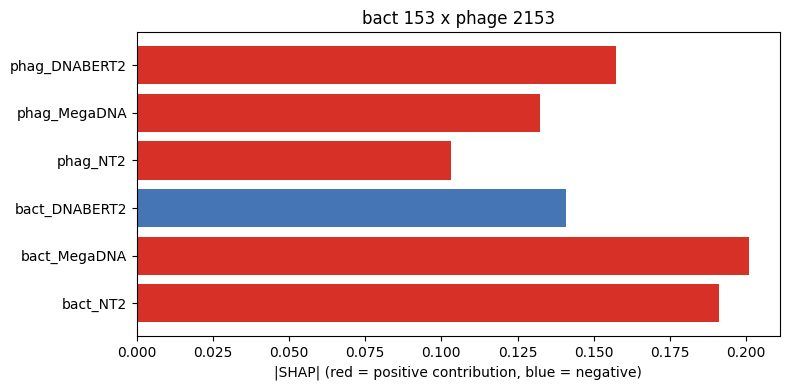

In [ ]:
block_contribs = {}

print('=== Block-level contributions ===')
for name, (s, e) in BLOCKS.items():
    contrib = float(sv.values[0, s:e].sum())
    block_contribs[name] = contrib
    print(f'  {name:<20s}: {contrib:+.6f}')

fig, ax = plt.subplots(figsize=(8, 4))
names  = list(block_contribs.keys())
raw    = list(block_contribs.values())


values = [abs(v) for v in raw]
colors = ['#d73027' if v > 0 else '#4575b4' for v in raw]

ax.barh(names, values, color=colors)
ax.set_xlabel('|SHAP| (red = positive contribution, blue = negative)')
ax.set_title(
    f'bact {row["bacterium_id"]} x phage {row["phage_id"]}'
)
plt.tight_layout()
plt.savefig('XAI/kernel_shap_single_abs.png', dpi=150)
plt.show()